# GreenDelivery — 01 Exploration

**Sujet blanc RNCP 38919 — Bloc 2**

Objectif : comprendre le dataset `data/raw/deliveries.json` avant toute transformation.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

CANDIDATES = [
    Path("../data/raw/deliveries.json"),
    Path("data/raw/deliveries.json"),
]
DATA_PATH = next(p for p in CANDIDATES if p.exists())

df = pd.read_json(DATA_PATH)
DATA_PATH


PosixPath('../data/raw/deliveries.json')

## 1. Aperçu et structure

In [2]:
display(df.head())
print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.info()


,delivery_id,customer_id,customer_city,vehicle_type,distance_km,traffic_level,weather,delivery_minutes,late_delivery
0,1001,501,Paris,bike,4.2,high,rain,38,1
1,1002,502,Poissy,car,18.4,medium,clear,42,0
2,1003,503,PARIS,bike,3.1,low,clear,19,0
3,1004,501,Paris,scooter,7.8,high,rain,47,1
4,1005,504,Versailles,car,15.0,medium,clear,34,0


shape: (24, 9)
columns: ['delivery_id', 'customer_id', 'customer_city', 'vehicle_type', 'distance_km', 'traffic_level', 'weather', 'delivery_minutes', 'late_delivery']
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   delivery_id       24 non-null     int64  
 1   customer_id       24 non-null     int64  
 2   customer_city     24 non-null     str    
 3   vehicle_type      24 non-null     str    
 4   distance_km       23 non-null     float64
 5   traffic_level     23 non-null     str    
 6   weather           23 non-null     str    
 7   delivery_minutes  24 non-null     int64  
 8   late_delivery     24 non-null     int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.8 KB


## 2. Valeurs manquantes

In [3]:
df.isna().sum()


delivery_id         0
customer_id         0
customer_city       0
vehicle_type        0
distance_km         1
traffic_level       1
weather             1
delivery_minutes    0
late_delivery       0
dtype: int64

## 3. Doublons

In [4]:
print("doublons complets :", df.duplicated().sum())
print("delivery_id dupliqués :", df["delivery_id"].duplicated().sum())
df[df["delivery_id"].duplicated(keep=False)]


doublons complets : 1
delivery_id dupliqués : 1


,delivery_id,customer_id,customer_city,vehicle_type,distance_km,traffic_level,weather,delivery_minutes,late_delivery
19,1020,519,Nanterre,scooter,8.9,medium,clear,33,0
20,1020,519,Nanterre,scooter,8.9,medium,clear,33,0


## 4. Distribution de la target

In [5]:
print(df["late_delivery"].value_counts())
df["late_delivery"].value_counts(normalize=True)


late_delivery
0    14
1    10
Name: count, dtype: int64


late_delivery
0    0.583333
1    0.416667
Name: proportion, dtype: float64

## 5. Variables catégorielles

In [6]:
for column in ["customer_city", "vehicle_type", "traffic_level", "weather"]:
    print(f"--- {column}")
    print(df[column].value_counts(dropna=False))


--- customer_city
customer_city
Paris                   6
Poissy                  5
Nanterre                5
Versailles              3
Boulogne-Billancourt    3
PARIS                   1
 Paris                  1
Name: count, dtype: int64
--- vehicle_type
vehicle_type
bike       8
car        8
scooter    8
Name: count, dtype: int64
--- traffic_level
traffic_level
medium    10
high       8
low        5
NaN        1
Name: count, dtype: int64
--- weather
weather
clear    11
rain      8
wind      4
NaN       1
Name: count, dtype: int64


## 6. Normalisation de customer_city

In [7]:
df["customer_city"] = df["customer_city"].astype("string").str.strip().str.lower()
df["customer_city"].value_counts()


customer_city
paris                   8
poissy                  5
nanterre                5
versailles              3
boulogne-billancourt    3
Name: count, dtype: Int64

## 7. Visualisations

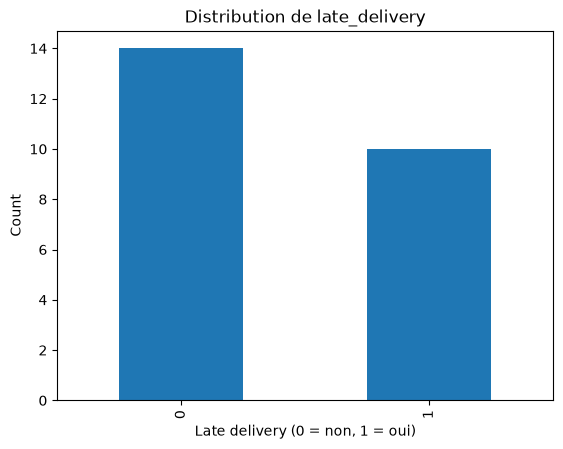

In [8]:
df["late_delivery"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de late_delivery")
plt.xlabel("Late delivery (0 = non, 1 = oui)")
plt.ylabel("Count")
plt.show()


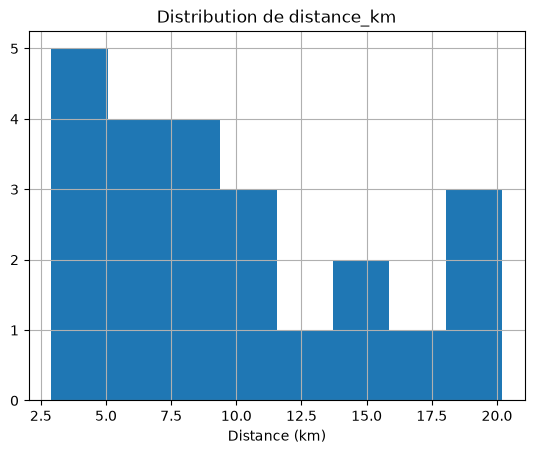

In [9]:
df["distance_km"].hist(bins=8)
plt.title("Distribution de distance_km")
plt.xlabel("Distance (km)")
plt.show()


## 8. Réponses aux questions d'exploration

1. **Grain** : une ligne = une livraison.
2. **Clé métier** : `delivery_id`.
3. **Doublons** : 1 doublon complet, qui est aussi un `delivery_id` dupliqué (1020).
4. **Valeurs manquantes** : `distance_km` (1), `traffic_level` (1), `weather` (1).
5. **Colonnes catégorielles** : `customer_city`, `vehicle_type`, `traffic_level`, `weather`.
6. **Normalisation `customer_city`** : oui — `Paris`, `PARIS`, ` Paris ` coexistent.
7. **Distribution `late_delivery`** : 0 ≈ 56,5 %, 1 ≈ 43,5 % avant déduplication.
8. **Variables utiles pour prédire** : `distance_km`, `traffic_level`, `weather`,
   `vehicle_type`, `customer_city`. `delivery_minutes` est écartée du modèle
   (fuite d'information) et les identifiants ne sont pas prédictifs.

**Décisions de nettoyage** (implémentées dans `src/etl.py`) :

- doublon `delivery_id` → conserver la première occurrence ;
- `distance_km` manquant → médiane ;
- `traffic_level` / `weather` manquants → `"unknown"` ;
- `customer_city` / `vehicle_type` → `strip()` + `lower()`.

Le dataset est **très petit** : toute métrique ML devra être interprétée avec prudence.
